<a href="https://colab.research.google.com/github/MidhulaMS/exit_exam_asteroid/blob/main/Asteroid_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.feature_selection import mutual_info_regression




import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Loading Dataset

In [3]:
filepath = "/content/drive/MyDrive/ICT AIML/Datasets/dataset.csv"
df_asteroid = pd.read_csv(filepath)

/tmp/ipykernel_35679/2231646775.py:2: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_asteroid = pd.read_csv(filepath)


# Task 1: EDA & Understanding

In [4]:
df_asteroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [5]:
df_asteroid.head()

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [6]:
df_asteroid.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [7]:
df_asteroid.shape

(958524, 45)

## Checking missing values

In [8]:
df_asteroid.isnull().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


## Checking duplicate records

In [9]:
df_asteroid.duplicated().sum()

np.int64(0)

## Distribution of asteroid diameter

In [10]:
df_asteroid['diameter'].value_counts()

,count
diameter,
4.017,45
3.296,45
3.122,44
3.537,44
3.008,44
...,...
0.124,1
0.055,1
0.057,1


## Plotting

### Distribution of H

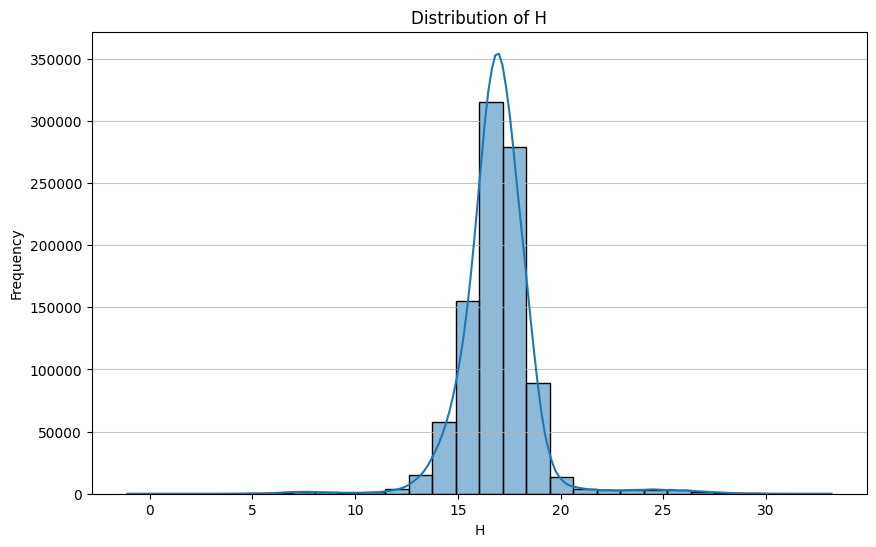

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df_asteroid['H'].dropna(), bins=30, kde=True)
plt.title('Distribution of H')
plt.xlabel('H')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Distribution of PHA

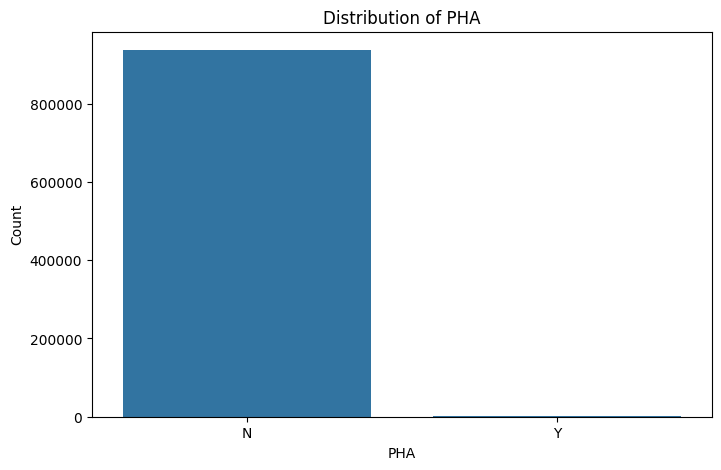

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df_asteroid['pha'].dropna())
plt.title('Distribution of PHA')
plt.xlabel('PHA')
plt.ylabel('Count')
plt.show()

### Relationship between H and Diameter

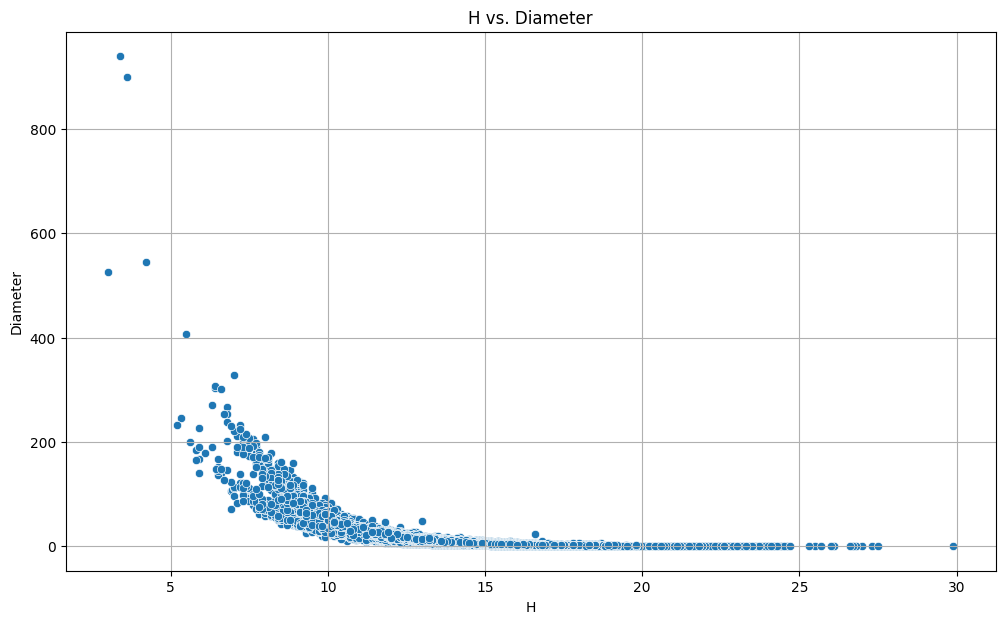

In [13]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='H', y='diameter', data=df_asteroid.dropna(subset=['H', 'diameter']))
plt.title('H vs. Diameter')
plt.xlabel('H')
plt.ylabel('Diameter')
plt.grid(True)
plt.show()

### Distribution of Asteroid Class

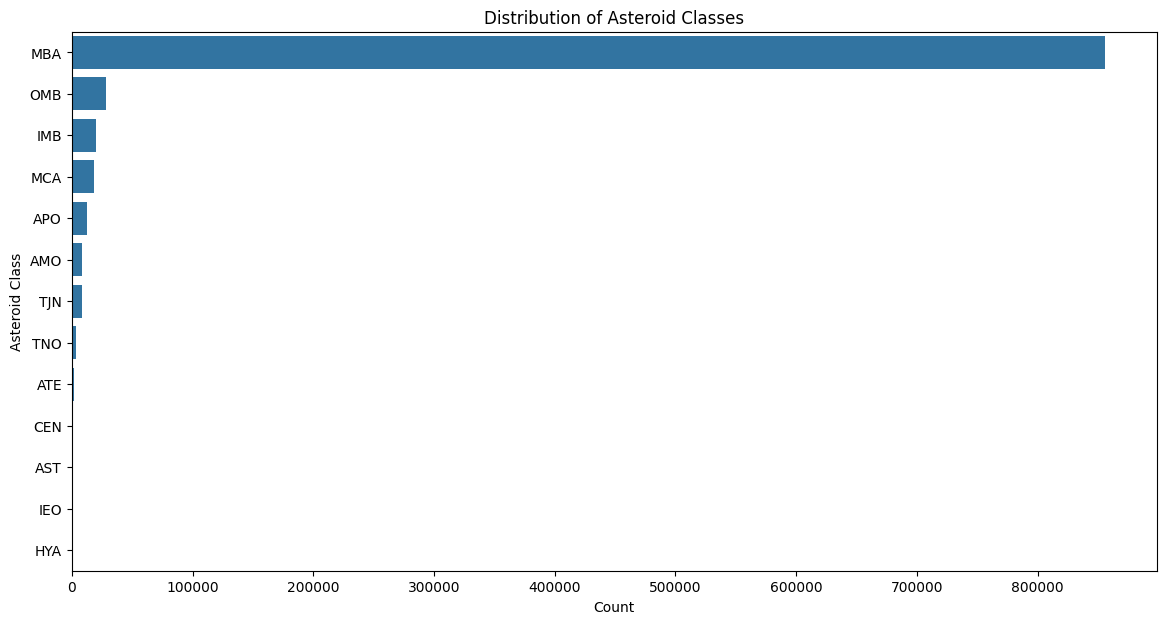

In [14]:
plt.figure(figsize=(14, 7))
sns.countplot(y='class', data=df_asteroid, order = df_asteroid['class'].value_counts().index)
plt.title('Distribution of Asteroid Classes')
plt.xlabel('Count')
plt.ylabel('Asteroid Class')
plt.show()

### Relationship between Diameter and e

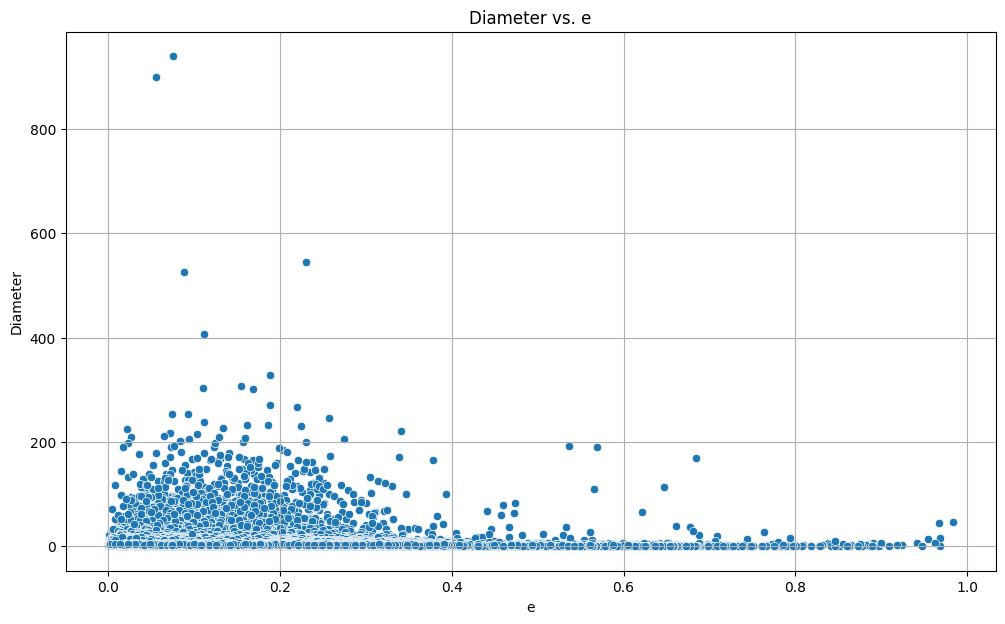

In [15]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='e', y='diameter', data=df_asteroid.dropna(subset=['diameter', 'e']))
plt.title('Diameter vs. e')
plt.xlabel('e')
plt.ylabel('Diameter')
plt.grid(True)
plt.show()

### Relationship between Diameter and a

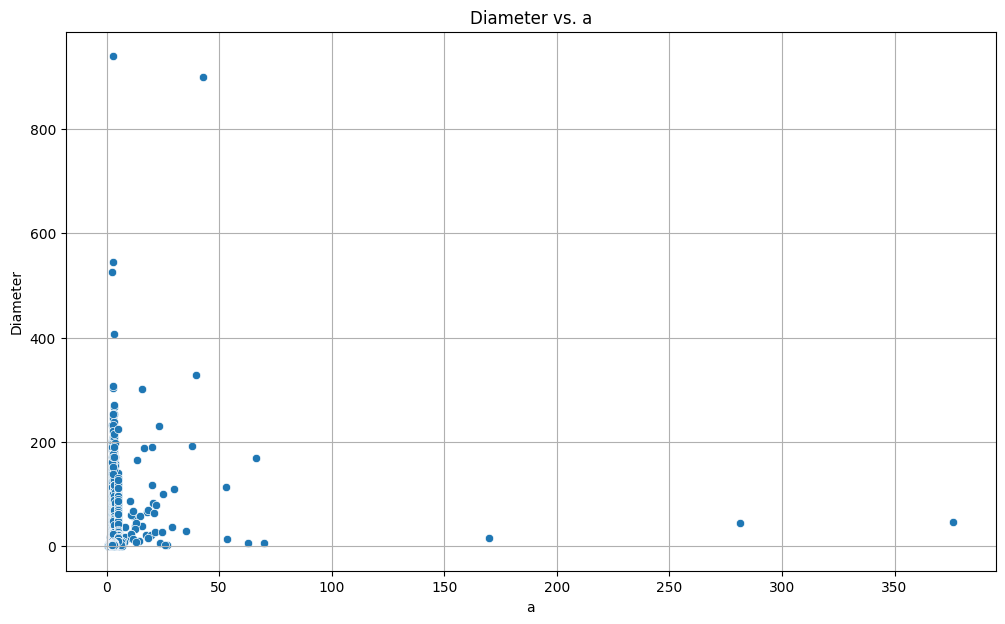

In [16]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='a', y='diameter', data=df_asteroid.dropna(subset=['diameter', 'a']))
plt.title('Diameter vs. a')
plt.xlabel('a')
plt.ylabel('Diameter')
plt.grid(True)
plt.show()

In [17]:
# mutual info
# target column
y = df_asteroid['diameter']
# X is a 2D array (Features)
X = df_asteroid.drop(columns = ['diameter'])

# Drop non-numeric columns from X
non_numeric_cols = X.select_dtypes(include=['object']).columns
X = X.drop(columns=non_numeric_cols)

# Drop rows where 'diameter' is NaN for accurate mutual information calculation
df_filtered = df_asteroid.dropna(subset=['diameter'])

# Drop non-numeric columns from df_filtered before dropping NaNs across X features
X_filtered_temp = df_filtered.drop(columns = ['diameter']).drop(columns=non_numeric_cols, errors='ignore')

# Drop rows with any NaNs from the X features and align y
df_cleaned = df_filtered.loc[X_filtered_temp.dropna().index]
X_filtered = df_cleaned.drop(columns=['diameter']).drop(columns=non_numeric_cols, errors='ignore')
y_filtered = df_cleaned['diameter']

mi = mutual_info_regression(X_filtered, y_filtered, random_state=42)
# converting mi values into a dataframe
# Creating two columns Features and mutual info
mi_df = pd.DataFrame({'Features': X_filtered.columns, 'mutual information':mi})
mi_df.sort_values(by='mutual information', ascending=False)

,Features,mutual information
2,albedo,1.455221
1,H,0.744886
20,moid,0.252191
21,moid_ld,0.252190
9,q,0.246075
8,a,0.243548
19,per_y,0.242435
18,per,0.242435
15,n,0.241600
0,spkid,0.200219


In [18]:
# num_cols= df_asteroid.select_dtypes(include=np.number)
# corr_mat = num_cols.corr()
# plt.figure(figsize = (170,150))
# sns.heatmap(corr_mat,annot = True)
# plt.show()

## Analytical Questions:
1. Target variable is skewed.
2. Feature 'h' has strong relationship with asteroid diameter
3.

# Data Preprocessing

## Missing value handling

In [19]:
df_asteroid.isnull().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


In [20]:
# majority of these columns are empty and the feature column name and full_name is similar
df_asteroid = df_asteroid.drop(columns=['name', 'prefix','albedo','diameter_sigma'])

In [21]:
df_asteroid.isnull().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
neo,4
pha,19921
H,6263
diameter,822315
orbit_id,0
epoch,0


In [22]:
# Drop irrelevant features which has low mutual info with target column diameter
df_asteroid = df_asteroid.drop(columns=['ma','epoch','om','w','epoch_cal','epoch_mjd'])
df_asteroid.isnull().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
neo,4
pha,19921
H,6263
diameter,822315
orbit_id,0
equinox,0


In [23]:
df_asteroid = df_asteroid.fillna(df_asteroid['H'].median())

In [24]:
df_asteroid.isnull().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
neo,0
pha,0
H,0
diameter,0
orbit_id,0
equinox,0


#### Remove irrelevant identifiers

In [25]:
df_asteroid = df_asteroid.drop(columns=['id'])
df_asteroid

,spkid,full_name,pdes,neo,pha,H,diameter,orbit_id,equinox,e,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,2000001,1 Ceres,1,N,N,3.400,939.400,JPL 47,J2000,0.076009,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,2000002,2 Pallas,2,N,N,4.200,545.000,JPL 37,J2000,0.229972,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,2000003,3 Juno,3,N,N,5.330,246.596,JPL 112,J2000,0.256936,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,2000004,4 Vesta,4,N,N,3.000,525.400,JPL 35,J2000,0.088721,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,2000005,5 Astraea,5,N,N,6.900,106.699,JPL 114,J2000,0.190913,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,3246801,(6013 P-L),6013 P-L,N,N,17.135,16.900,JPL 5,J2000,0.185919,...,6.969000e+00,7.433000e+00,4.631100e+01,2.738300e+01,1.041200e+00,1.652100e-01,1.309700e+02,7.264900e+02,MBA,0.23839
958520,3246834,(6331 P-L),6331 P-L,N,N,18.500,16.900,8,J2000,0.282920,...,1.563500e-05,5.598600e-05,2.380400e-04,1.298200e-04,2.418900e-08,3.346100e-09,4.690200e-04,1.578500e-05,MBA,0.53633
958521,3013075,(6344 P-L),6344 P-L,Y,Y,20.400,16.900,17,J2000,0.662446,...,1.853300e-05,5.691700e-05,8.969200e-05,5.272600e-05,1.650100e-07,1.101600e-08,2.830600e-04,9.127500e-05,APO,0.51556
958522,3246457,(2060 T-2),2060 T-2,N,N,18.071,16.900,JPL 3,J2000,0.202053,...,5.448800e-01,4.391600e+00,1.898800e+01,1.083800e+01,7.171600e-01,1.016700e-01,3.898400e+01,5.035500e+02,MBA,0.25641


In [26]:
# Remove rows where diameter is missing
df_asteroid = df_asteroid.dropna(subset=['diameter']).copy()

## Encoding

In [27]:
num_cols = df_asteroid.select_dtypes(include=np.number)
num_cols

,spkid,H,diameter,e,a,q,i,ad,n,tp,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
0,2000001,3.400,939.400,0.076009,2.769165,2.558684,10.594067,2.979647,0.213885,2.458239e+06,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.43301
1,2000002,4.200,545.000,0.229972,2.773841,2.135935,34.832932,3.411748,0.213345,2.458321e+06,...,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,0.35936
2,2000003,5.330,246.596,0.256936,2.668285,1.982706,12.991043,3.353865,0.226129,2.458446e+06,...,8.139200e-08,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,0.33848
3,2000004,3.000,525.400,0.088721,2.361418,2.151909,7.141771,2.570926,0.271609,2.458248e+06,...,1.928600e-09,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,0.39980
4,2000005,6.900,106.699,0.190913,2.574037,2.082619,5.367427,3.065455,0.238661,2.458926e+06,...,6.092400e-08,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,0.52191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,3246801,17.135,16.900,0.185919,2.280861,1.856807,5.984416,2.704916,0.286125,2.437266e+06,...,7.299800e-01,6.969000e+00,7.433000e+00,4.631100e+01,2.738300e+01,1.041200e+00,1.652100e-01,1.309700e+02,7.264900e+02,0.23839
958520,3246834,18.500,16.900,0.282920,2.334910,1.674319,8.082280,2.995502,0.276248,2.459362e+06,...,6.256300e-07,1.563500e-05,5.598600e-05,2.380400e-04,1.298200e-04,2.418900e-08,3.346100e-09,4.690200e-04,1.578500e-05,0.53633
958521,3013075,20.400,16.900,0.662446,2.817152,0.950941,4.679278,4.683363,0.208444,2.459574e+06,...,1.687100e-07,1.853300e-05,5.691700e-05,8.969200e-05,5.272600e-05,1.650100e-07,1.101600e-08,2.830600e-04,9.127500e-05,0.51556
958522,3246457,18.071,16.900,0.202053,2.373137,1.893638,0.732484,2.852636,0.269600,2.441974e+06,...,5.478400e-01,5.448800e-01,4.391600e+00,1.898800e+01,1.083800e+01,7.171600e-01,1.016700e-01,3.898400e+01,5.035500e+02,0.25641


In [28]:
cat_cols = df_asteroid.select_dtypes(include = 'object')
cat_cols

,full_name,pdes,neo,pha,orbit_id,equinox,class
0,1 Ceres,1,N,N,JPL 47,J2000,MBA
1,2 Pallas,2,N,N,JPL 37,J2000,MBA
2,3 Juno,3,N,N,JPL 112,J2000,MBA
3,4 Vesta,4,N,N,JPL 35,J2000,MBA
4,5 Astraea,5,N,N,JPL 114,J2000,MBA
...,...,...,...,...,...,...,...
958519,(6013 P-L),6013 P-L,N,N,JPL 5,J2000,MBA
958520,(6331 P-L),6331 P-L,N,N,8,J2000,MBA
958521,(6344 P-L),6344 P-L,Y,Y,17,J2000,APO
958522,(2060 T-2),2060 T-2,N,N,JPL 3,J2000,MBA


In [29]:
df_asteroid['full_name'].nunique()

958524

In [30]:
# majority of them are different, so there is no relation b/w target column. So drop this feature column
df_asteroid = df_asteroid.drop(columns=['full_name'])


## Binary Encoding

In [31]:
df_asteroid['neo'] = df_asteroid['neo'].map({'Y': 1, 'N': 0})
df_asteroid['pha'] = df_asteroid['pha'].map({'Y': 1, 'N': 0})
df_asteroid.head()

,spkid,pdes,neo,pha,H,diameter,orbit_id,equinox,e,a,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,2000001,1,0.0,0.0,3.40,939.400,JPL 47,J2000,0.076009,2.769165,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,2000002,2,0.0,0.0,4.20,545.000,JPL 37,J2000,0.229972,2.773841,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,2000003,3,0.0,0.0,5.33,246.596,JPL 112,J2000,0.256936,2.668285,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,2000004,4,0.0,0.0,3.00,525.400,JPL 35,J2000,0.088721,2.361418,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,2000005,5,0.0,0.0,6.90,106.699,JPL 114,J2000,0.190913,2.574037,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [32]:
df_asteroid['equinox'].unique()

array(['J2000'], dtype=object)

In [33]:
df_asteroid['equinox'].nunique()

1

In [34]:
df_asteroid['equinox'] = df_asteroid['equinox'].map({'J2000': 1})

In [35]:
df_asteroid.head()

,spkid,pdes,neo,pha,H,diameter,orbit_id,equinox,e,a,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,2000001,1,0.0,0.0,3.40,939.400,JPL 47,1,0.076009,2.769165,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,2000002,2,0.0,0.0,4.20,545.000,JPL 37,1,0.229972,2.773841,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,2000003,3,0.0,0.0,5.33,246.596,JPL 112,1,0.256936,2.668285,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,2000004,4,0.0,0.0,3.00,525.400,JPL 35,1,0.088721,2.361418,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,2000005,5,0.0,0.0,6.90,106.699,JPL 114,1,0.190913,2.574037,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [36]:
df_asteroid['orbit_id'].nunique()


4690

In [37]:
# Encoding is not applicabe for the feature column orbit_id.And it won't give any relation with target column. So orbit_id can be drop due to beacuse it is an identifier
df_asteroid = df_asteroid.drop(columns=['orbit_id'])
df_asteroid.head()

,spkid,pdes,neo,pha,H,diameter,equinox,e,a,q,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,2000001,1,0.0,0.0,3.40,939.400,1,0.076009,2.769165,2.558684,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,2000002,2,0.0,0.0,4.20,545.000,1,0.229972,2.773841,2.135935,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,2000003,3,0.0,0.0,5.33,246.596,1,0.256936,2.668285,1.982706,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,2000004,4,0.0,0.0,3.00,525.400,1,0.088721,2.361418,2.151909,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,2000005,5,0.0,0.0,6.90,106.699,1,0.190913,2.574037,2.082619,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [38]:
if 'class' in df_asteroid.columns:
    df_asteroid = pd.get_dummies(
        df_asteroid,
        columns=['class'],
        drop_first=True
    )

print("Shape after encoding:", df_asteroid.shape)

Shape after encoding: (958524, 43)


In [39]:
df_asteroid.head()

,spkid,pdes,neo,pha,H,diameter,equinox,e,a,q,...,class_ATE,class_CEN,class_HYA,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,2000001,1,0.0,0.0,3.40,939.400,1,0.076009,2.769165,2.558684,...,False,False,False,False,False,True,False,False,False,False
1,2000002,2,0.0,0.0,4.20,545.000,1,0.229972,2.773841,2.135935,...,False,False,False,False,False,True,False,False,False,False
2,2000003,3,0.0,0.0,5.33,246.596,1,0.256936,2.668285,1.982706,...,False,False,False,False,False,True,False,False,False,False
3,2000004,4,0.0,0.0,3.00,525.400,1,0.088721,2.361418,2.151909,...,False,False,False,False,False,True,False,False,False,False
4,2000005,5,0.0,0.0,6.90,106.699,1,0.190913,2.574037,2.082619,...,False,False,False,False,False,True,False,False,False,False


In [40]:
## Check whether all columns are numerical
df_asteroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 43 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   spkid      958524 non-null  int64  
 1   pdes       958524 non-null  object 
 2   neo        958520 non-null  float64
 3   pha        938603 non-null  float64
 4   H          958524 non-null  float64
 5   diameter   958524 non-null  float64
 6   equinox    958524 non-null  int64  
 7   e          958524 non-null  float64
 8   a          958524 non-null  float64
 9   q          958524 non-null  float64
 10  i          958524 non-null  float64
 11  ad         958524 non-null  float64
 12  n          958524 non-null  float64
 13  tp         958524 non-null  float64
 14  tp_cal     958524 non-null  float64
 15  per        958524 non-null  float64
 16  per_y      958524 non-null  float64
 17  moid       958524 non-null  float64
 18  moid_ld    958524 non-null  float64
 19  sigma_e    958524 non-n

In [41]:
bool_cols = df_asteroid.select_dtypes(include='bool').columns

df_asteroid[bool_cols] = df_asteroid[bool_cols].astype(int)

In [42]:
df_asteroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 43 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   spkid      958524 non-null  int64  
 1   pdes       958524 non-null  object 
 2   neo        958520 non-null  float64
 3   pha        938603 non-null  float64
 4   H          958524 non-null  float64
 5   diameter   958524 non-null  float64
 6   equinox    958524 non-null  int64  
 7   e          958524 non-null  float64
 8   a          958524 non-null  float64
 9   q          958524 non-null  float64
 10  i          958524 non-null  float64
 11  ad         958524 non-null  float64
 12  n          958524 non-null  float64
 13  tp         958524 non-null  float64
 14  tp_cal     958524 non-null  float64
 15  per        958524 non-null  float64
 16  per_y      958524 non-null  float64
 17  moid       958524 non-null  float64
 18  moid_ld    958524 non-null  float64
 19  sigma_e    958524 non-n

## Analytical ques

###1. Feature Scaling
We need to check the data distribution of continous features.



   min-max Scaler: used for skewed distribution.
     Result: Values are scaled in between 0 and 1.
   Standard Scaler: Used for symmetric distribution.  
     Result: values will be scaled in such a way that mean = 0 and standard deviation is 1.

2. Identifiers, ma, epoch, om, w, epoch_cal, epoch_mjd are the columns that i    dropped.

3. albedo, h are the feature columns that are closely related to target column diameter.




## Scaling

In [43]:
# Ensure the DataFrame is fully prepared before defining X and y

# Create a clean working copy of the DataFrame
df_cleaned_for_model = df_asteroid.copy()

# 1. Drop irrelevant and identifier columns that might still be present or cause issues.
columns_to_re_drop = [
    'pdes',  # Identified as object type and identifier
    'name', 'prefix', 'albedo', 'diameter_sigma',  # Identified as highly missing/irrelevant
    'ma', 'epoch', 'om', 'w', 'epoch_cal', 'epoch_mjd',  # Identified as low mutual info
    'id', 'full_name', 'orbit_id'  # Identified as identifiers
]
df_cleaned_for_model = df_cleaned_for_model.drop(columns=columns_to_re_drop, errors='ignore')


if 'neo' in df_cleaned_for_model.columns:
    df_cleaned_for_model['neo'].fillna(df_cleaned_for_model['neo'].mode()[0], inplace=True)
if 'pha' in df_cleaned_for_model.columns:
    df_cleaned_for_model['pha'].fillna(df_cleaned_for_model['pha'].mode()[0], inplace=True)

#  Final robust NaN handling: Drop any remaining rows with NaNs across all columns.
#    This guarantees that X and y are fully numeric and free of missing values.
df_cleaned_for_model = df_cleaned_for_model.dropna()

# Now define X and y from the thoroughly cleaned DataFrame.
X = df_cleaned_for_model.drop(columns=['diameter'])
y = df_cleaned_for_model['diameter']

/tmp/ipykernel_35679/1526412742.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned_for_model['neo'].fillna(df_cleaned_for_model['neo'].mode()[0], inplace=True)
/tmp/ipykernel_35679/1526412742.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

In [45]:
df_asteroid.head()

,spkid,pdes,neo,pha,H,diameter,equinox,e,a,q,...,class_ATE,class_CEN,class_HYA,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,2000001,1,0.0,0.0,3.40,939.400,1,0.076009,2.769165,2.558684,...,0,0,0,0,0,1,0,0,0,0
1,2000002,2,0.0,0.0,4.20,545.000,1,0.229972,2.773841,2.135935,...,0,0,0,0,0,1,0,0,0,0
2,2000003,3,0.0,0.0,5.33,246.596,1,0.256936,2.668285,1.982706,...,0,0,0,0,0,1,0,0,0,0
3,2000004,4,0.0,0.0,3.00,525.400,1,0.088721,2.361418,2.151909,...,0,0,0,0,0,1,0,0,0,0
4,2000005,5,0.0,0.0,6.90,106.699,1,0.190913,2.574037,2.082619,...,0,0,0,0,0,1,0,0,0,0


In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,spkid,neo,pha,H,equinox,e,a,q,i,ad,...,class_ATE,class_CEN,class_HYA,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
307413,-0.219806,-0.156241,-0.046338,-0.507223,0.0,-0.934179,-0.016757,-0.021061,0.552939,-0.029066,...,-0.042706,-0.022788,-0.001978,-0.004845,-0.147487,0.345952,-0.140721,-0.174358,-0.09319,-0.060364
376242,-0.209708,-0.156241,-0.046338,-0.395187,0.0,-0.742357,-0.003689,0.072647,-0.264369,-0.014717,...,-0.042706,-0.022788,-0.001978,-0.004845,-0.147487,0.345952,-0.140721,-0.174358,-0.09319,-0.060364
850738,-0.001447,-0.156241,-0.046338,0.277026,0.0,-0.274870,-0.017244,-0.096902,-0.536472,-0.023005,...,-0.042706,-0.022788,-0.001978,-0.004845,-0.147487,0.345952,-0.140721,-0.174358,-0.09319,-0.060364
355661,-0.212728,-0.156241,-0.046338,-0.451205,0.0,1.111549,0.014290,-0.022708,-0.339704,0.025471,...,-0.042706,-0.022788,-0.001978,-0.004845,-0.147487,0.345952,-0.140721,-0.174358,-0.09319,-0.060364
632100,0.028153,-0.156241,-0.046338,0.143143,0.0,-0.107885,0.013252,0.135198,-0.341640,0.009258,...,-0.042706,-0.022788,-0.001978,-0.004845,-0.147487,0.345952,-0.140721,-0.174358,-0.09319,-0.060364


# Task 3: Deep Neural Network

In [48]:
def build_model(learning_rate=0.001, dropout_rate=0.2):

    model = Sequential([
        Dense(128, activation='relu',
              input_shape=(X_train_scaled.shape[1],)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),

        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )

    return model

In [49]:
learning_rates = [0.001, 0.0005, 0.0001]
dropout_rates = [0.1, 0.2, 0.3]

In [ ]:
# Train and compare models
results = []

for lr in learning_rates:
    for dropout in dropout_rates:

        print(f"\nLearning Rate: {lr}, Dropout: {dropout}")

        model = build_model(
            learning_rate=lr,
            dropout_rate=dropout
        )

        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_scaled,
            y_train,
            validation_split=0.2,
            epochs=50,
            batch_size=64,
            callbacks=[early_stopping],
            verbose=1
        )

        y_pred = model.predict(
            X_test_scaled,
            verbose=0
        ).flatten()


        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Learning Rate': lr,
            'Dropout': dropout,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })


Learning Rate: 0.001, Dropout: 0.1


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 19.5335 - mae: 2.5606 - val_loss: 271.0802 - val_mae: 2.3607
Epoch 2/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 74s 8ms/step - loss: 16.5792 - mae: 2.2646 - val_loss: 57.8548 - val_mae: 2.1661
Epoch 3/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 16.0385 - mae: 2.1891 - val_loss: 24.9068 - val_mae: 1.9849
Epoch 4/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 15.8001 - mae: 2.1520 - val_loss: 172.4116 - val_mae: 2.0735
Epoch 5/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - loss: 15.7795 - mae: 2.1264 - val_loss: 37.3287 - val_mae: 2.1873
Epoch 6/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - loss: 15.5387 - mae: 2.1087 - val_loss: 69.8758 - val_mae: 1.9641
Epoch 7/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 15.5313 - mae: 2.0959 - val_loss: 44.2181 - val_mae: 2.3452
Epoch 8/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 15.3816 - mae: 2.0902 - val_loss: 51.6861 - val_mae: 1.9799
Epoch 9/50
958

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 20.2063 - mae: 2.6262 - val_loss: 146.4009 - val_mae: 2.7085
Epoch 2/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 17.0362 - mae: 2.2891 - val_loss: 32.3620 - val_mae: 2.0566
Epoch 3/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 16.5349 - mae: 2.2009 - val_loss: 2462.7661 - val_mae: 2.3576
Epoch 4/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 16.2826 - mae: 2.1628 - val_loss: 25.0309 - val_mae: 1.9747
Epoch 5/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 16.1281 - mae: 2.1440 - val_loss: 632.1128 - val_mae: 2.0803
Epoch 6/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 16.0073 - mae: 2.1268 - val_loss: 26.9395 - val_mae: 2.2016
Epoch 7/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 15.8457 - mae: 2.1135 - val_loss: 23.6949 - val_mae: 2.1991
Epoch 8/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 15.8454 - mae: 2.1044 - val_loss: 146.7005 - val_mae: 1.9549
Epoch 9/50


...

Epoch 1/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 21.4601 - mae: 2.7484 - val_loss: 774.4870 - val_mae: 2.5393
Epoch 2/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 17.2558 - mae: 2.3198 - val_loss: 297.4805 - val_mae: 2.3093
Epoch 3/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 16.9893 - mae: 2.2424 - val_loss: 702.7776 - val_mae: 2.1766
Epoch 4/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 16.5879 - mae: 2.2079 - val_loss: 25.7319 - val_mae: 2.4591
Epoch 5/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 16.5502 - mae: 2.1903 - val_loss: 28.2865 - val_mae: 2.2819
Epoch 6/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 16.3394 - mae: 2.1748 - val_loss: 24.5710 - val_mae: 2.1011
Epoch 7/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 16.3160 - mae: 2.1632 - val_loss: 109.9105 - val_mae: 2.1923
Epoch 8/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 16.1605 - mae: 2.1537 - val_loss: 23.7976 - val_mae: 1.8567
Epoch 9/50
9

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - loss: 21.2941 - mae: 2.6955 - val_loss: 125.2758 - val_mae: 2.2746
Epoch 2/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 16.4221 - mae: 2.3276 - val_loss: 3041.4678 - val_mae: 2.6143
Epoch 3/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 15.9185 - mae: 2.2474 - val_loss: 63.1932 - val_mae: 2.1048
Epoch 4/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 15.6491 - mae: 2.2001 - val_loss: 108.2588 - val_mae: 2.2316
Epoch 5/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 15.5672 - mae: 2.1631 - val_loss: 398.3705 - val_mae: 2.2480
Epoch 6/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 15.3187 - mae: 2.1368 - val_loss: 27.0320 - val_mae: 2.0313
Epoch 7/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 15.3479 - mae: 2.1166 - val_loss: 14988.1338 - val_mae: 2.8213
Epoch 8/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 15.2647 - mae: 2.1030 - val_loss: 4447.0054 - val_mae: 2.4394
Epoch 

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 23.8153 - mae: 2.9095 - val_loss: 5618.6855 - val_mae: 2.8181
Epoch 2/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 17.1269 - mae: 2.3866 - val_loss: 190.1805 - val_mae: 2.4657
Epoch 3/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 16.3786 - mae: 2.2636 - val_loss: 1480.7733 - val_mae: 2.3415
Epoch 4/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 16.2409 - mae: 2.2021 - val_loss: 655.5917 - val_mae: 2.1568
Epoch 5/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 15.9350 - mae: 2.1617 - val_loss: 53.8880 - val_mae: 2.0432
Epoch 6/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 15.7579 - mae: 2.1400 - val_loss: 110.5224 - val_mae: 2.0455
Epoch 7/50
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 15.8068 - mae: 2.1283 - val_loss: 38.5697 - val_mae: 2.0110
Epoch 8/50


In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by='RMSE',
    ascending=True
)

In [ ]:
best_lr = best_result['Learning Rate']
best_dropout = best_result['Dropout']

final_model = build_model(
    learning_rate=best_lr,
    dropout_rate=best_dropout
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=5,
    callbacks=[early_stopping],
    verbose=1
)

In [ ]:
# ## training
# best_lr = best_result['Learning Rate']
# best_dropout = best_result['Dropout']

# final_model = build_model(
#     learning_rate=best_lr,
#     dropout_rate=best_dropout
# )

# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=10,
#     restore_best_weights=True
# )

# final_history = final_model.fit(
#     X_train_scaled,
#     y_train,
#     validation_split=0.2,
#     epochs=100,
#     batch_size=64,
#     callbacks=[early_stopping],
#     verbose=1
# )

### Plotting training and validation loss

In [ ]:
# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

In [ ]:
import pickle

with open("/content/skinova_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully at /content/skinova_model.pkl")